# Compute Drawdowns

In [ ]:
import pandas as pd
import numpy as npb

In [3]:
me_m =  pd.read_csv("data/Portfolios_Formed_on_ME_monthly_EW.csv"
                    , header = 0, index_col =0, na_values = -99)

In [6]:
rets = me_m[['Lo 10', 'Hi 10']]
rets.columns = ["Small Cap", "Large Cap"]
rets = rets/100
rets

,Small Cap,Large Cap
192607,-0.0145,0.0329
192608,0.0512,0.0370
192609,0.0093,0.0067
192610,-0.0484,-0.0243
192611,-0.0078,0.0270
...,...,...
201808,0.0241,0.0234
201809,-0.0168,0.0087
201810,-0.1002,-0.0657
201811,-0.0365,0.0253


<Axes: >

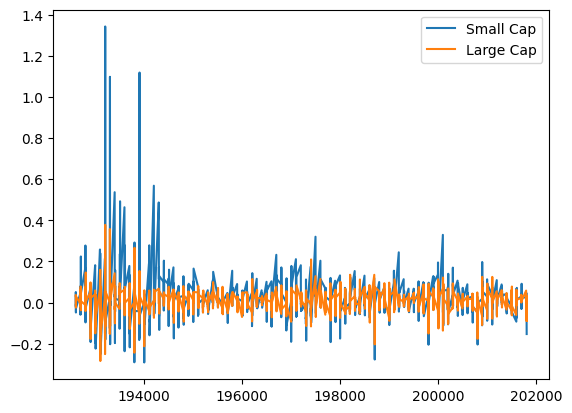

In [8]:
rets.plot.line()

In [11]:
rets.index = pd.to_datetime(rets.index, format="%Y%m")
rets.index

DatetimeIndex(['1926-07-01', '1926-08-01', '1926-09-01', '1926-10-01',
               '1926-11-01', '1926-12-01', '1927-01-01', '1927-02-01',
               '1927-03-01', '1927-04-01',
               ...
               '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01',
               '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01',
               '2018-11-01', '2018-12-01'],
              dtype='datetime64[ns]', length=1110, freq=None)

In [16]:
rets.head()

,Small Cap,Large Cap
1926-07,-0.0145,0.0329
1926-08,0.0512,0.0370
1926-09,0.0093,0.0067
1926-10,-0.0484,-0.0243
1926-11,-0.0078,0.0270


# Compute DrawDowns

1. Compute a wealth index
2. Compute previous peaks
3. Compute drawdown - which is the wealth value as a percentage of the previous peak

In [19]:
wealth_index = 1000*(1+rets["Large Cap"]).cumprod()
wealth_index

1926-07    1.032900e+03
1926-08    1.071117e+03
1926-09    1.078294e+03
1926-10    1.052091e+03
1926-11    1.080498e+03
               ...     
2018-08    4.175915e+06
2018-09    4.212246e+06
2018-10    3.935501e+06
2018-11    4.035069e+06
2018-12    3.675948e+06
Freq: M, Name: Large Cap, Length: 1110, dtype: float64

<Axes: >

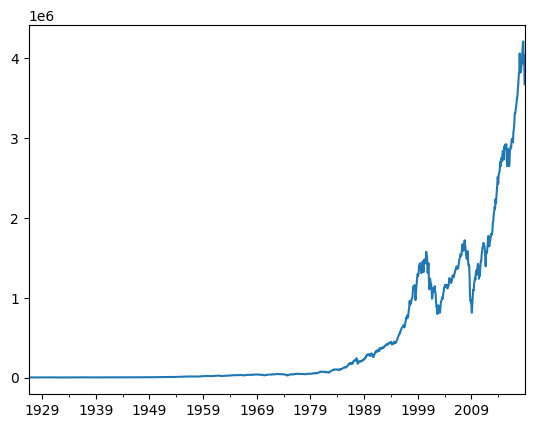

In [20]:
wealth_index.plot.line()

In [ ]:
previous_peak = wealth_index.cummax()

<Axes: >

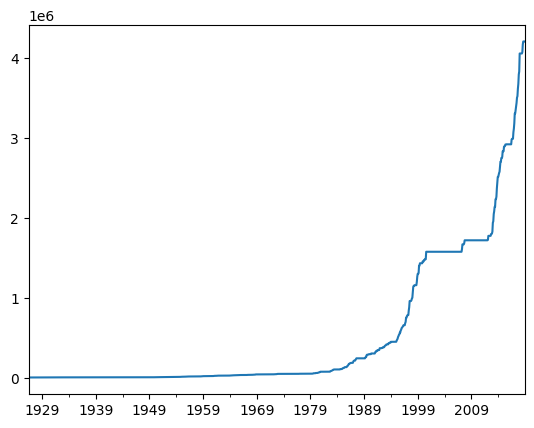

In [22]:
previous_peak.plot.line()

<Axes: >

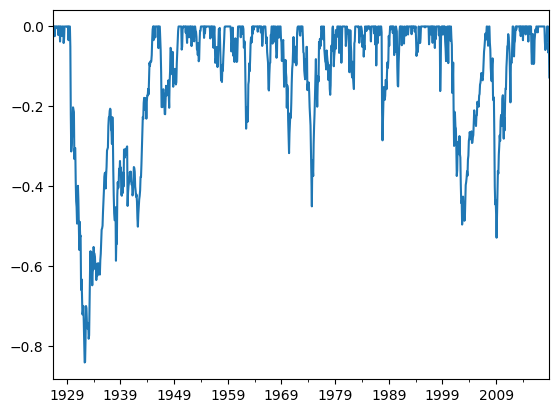

In [24]:
draw_down = (wealth_index - previous_peak)/previous_peak
draw_down.plot.line()

In [37]:
previous_peak

1926-07    1.032900e+03
1926-08    1.071117e+03
1926-09    1.078294e+03
1926-10    1.078294e+03
1926-11    1.080498e+03
               ...     
2018-08    4.175915e+06
2018-09    4.212246e+06
2018-10    4.212246e+06
2018-11    4.212246e+06
2018-12    4.212246e+06
Freq: M, Name: Large Cap, Length: 1110, dtype: float64

In [ ]:
draw_down["1975"].idxmin()

Period('1975-01', 'M')

In [44]:
def drawdown(return_series : pd.Series):
    """
    Take a time series of asset return
    Computed and return a Dataframe that consist:
    the wealth index
    the previous peak
    drawdown
    """
    wealth_index = 1000*(1+return_series).cumprod()
    previous_peak = wealth_index.cummax()
    drawdown = (wealth_index/previous_peak) - 1
    return pd.DataFrame({
        "Wealth": wealth_index,
        "Peaks": previous_peak,
        "Drawdown": drawdown
    })

In [45]:
drawdown(rets["Large Cap"]).head()

,Wealth,Peaks,Drawdown
1926-07,1032.900000,1032.900000,0.0000
1926-08,1071.117300,1071.117300,0.0000
1926-09,1078.293786,1078.293786,0.0000
1926-10,1052.091247,1078.293786,-0.0243
1926-11,1080.497711,1080.497711,0.0000


In [48]:
drawdown(rets["Large Cap"])["Drawdown"].min()

-0.8400375277943123

In [49]:
drawdown(rets["Small Cap"])["Drawdown"].min()

-0.8330007793945303

In [51]:
drawdown(rets["Large Cap"])["Drawdown"].idxmin()

Period('1932-05', 'M')